# Lithium-Boom — did riding the battery-metals boom pay, or just whipsaw you? 🔋
### A trend-follower on the lithium theme (LIT), tested honestly, in plain English

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Did_riding_the_boom_pay%3F: Misattributed](https://img.shields.io/badge/Did_riding_the_boom_pay%3F-Misattributed-8b949e?style=flat-square)

Around 2021 the pitch was everywhere: lithium is *the new oil*, the battery-metals **super-cycle** is a structural multi-year bull market, and a simple trend-follower riding the **LIT** ETF would have caught the boom *and* stepped aside before the bust. Then the metal roughly tripled and gave most of it back. This notebook asks the only two questions that matter: *did the trend rule carry real information — and did it actually pay you, or just hand you a smaller scare?*

> **This is the plain-language layer.** Want the t-stats, the apples-to-apples race and the bootstrap CI? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from lithium_boom import data, strategy as st

ASOF = "2026-06-17"
RF = 0.015
RF_D = RF / st.TRADING_DAYS_PER_YEAR
THEME = data.THEME_TICKERS  # LIT, ALB, SQM

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE))
               for t in data.ALL_TICKERS)

HAVE_REAL = _have_cache()

def load(t):
    b = data.fetch_daily(t, fetch=False)
    return b[b.index <= ASOF]

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first 🎯

| Question | Answer |
|---|---|
| Did the trend rule know *something*? | **Yes.** Its timing crushes a coin that trades just as often (the trend sits at the **100th percentile** of random timing). The signal is real. |
| Did it ride the boom for *return*? | **No.** Versus simply holding LIT, the overlay added **~0%/yr** (difference too small to measure). What it really did was **halve the drawdown** (-66% → -41%). |
| So would you be richer? | **Barely — and not the way you were sold.** You got a calmer ride, not a bigger pile. And the whole battery-metals sleeve still earned **worse** risk-adjusted returns than just owning the S&P 500. |
| So what is it? | A real *crash-dodging* tool dressed up as a *boom-riding* one — useful for sleep, useless as the get-rich story the cycle was marketed as. |

> The trend rule isn't fake — it genuinely times the theme. But '*ride the boom*' is the wrong frame: it paid you in a smaller drawdown, not in the runaway return the super-cycle pitch promised.

## 1 · The claim

> *"Electrification is structural: lithium and battery materials are in a multi-year super-cycle. Own the theme through **LIT** (or the miners), follow the trend, and you'll ride the boom — and because you follow the trend, you'll be out before the bust."*

— the 2021–22 battery-metals super-cycle narrative (Global X fund literature; Goldman / Benchmark Mineral Intelligence cycle notes)

The mechanical version we test is the oldest trend rule there is (Faber 2007): **hold the asset when its price is above its 200-day moving average; otherwise sit in cash.** It rests on something real — *time-series momentum* (Moskowitz-Ooi-Pedersen 2012): an asset's own trend tends to persist. The question is what that buys you on a single, wild commodity theme.

## 2 · So what?

Two things make this worth a careful look. First, LIT is a textbook **boom-bust**: it roughly tripled into 2021–22 then fell ~65%. If trend-following *ever* earns its keep, it should be here — a long, smooth ride up and a long, grinding ride down. Second, the pitch quietly blends two very different promises: '*you'll ride the boom*' (a **return** claim) and '*you'll dodge the bust*' (a **risk** claim). Those are not the same thing, and almost every 'trend timing' write-up you'll read leans on the first while only the second is actually true. Untangling them is the lesson that transfers.

## 3 · How would we even know?

Three checks keep us honest:

1. **Race it against just holding the thing.** A timing overlay is only interesting if it beats buy-and-hold. Because it sits in cash part-time, we compare them *fairly* (both measured against cash).
2. **Race it against a coin that trades as often.** Place the same number of in/out moves on *random* days. If the trend rule beats that, the *timing* — not just being in cash sometimes — carried information.
3. **Separate 'calmer' from 'richer'.** Measure the drawdown *and* the return-vs-hold difference, side by side, so a smaller scare can't masquerade as a bigger pile.

Tape: LIT total-return daily bars from the fund's 2010 launch (plus miners ALB, SQM, and SPY as the benchmark). As-of 2026-06-17. Costs: 10 bps one-way on every flip.

## 4 · The teardown — let's actually look

**First, the picture everyone remembers — the boom and the bust, and where the trend rule was in vs out:**

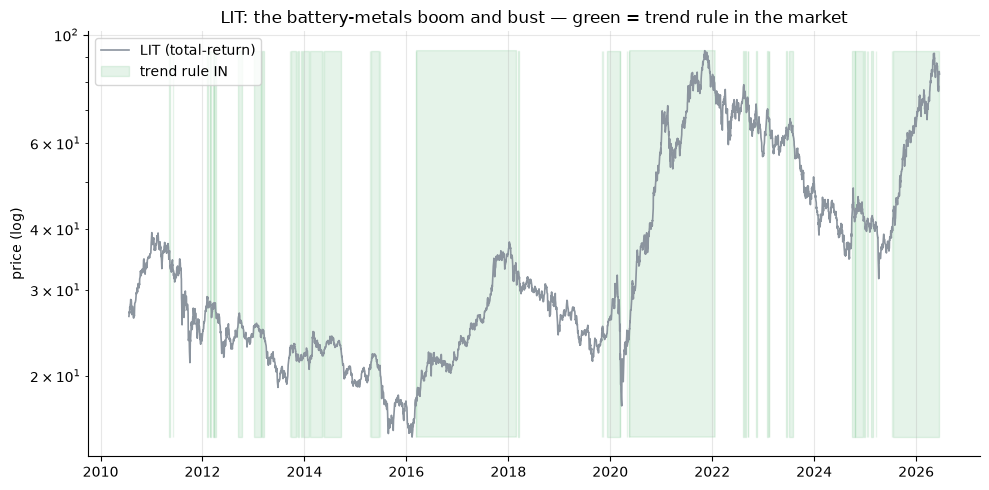

Banner: REAL LIT tape


In [2]:
if HAVE_REAL:
    b = load('LIT'); sig = st.trend_signal(b, 200)
    pos = sig.shift(1).fillna(0.0)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(b.index, b['close'], c=GREY, lw=1.2, label='LIT (total-return)')
    ax.fill_between(b.index, b['close'].min(), b['close'].max(),
                    where=pos.to_numpy() > 0.5, color=GREEN, alpha=.12,
                    step='post', label='trend rule IN')
    ax.set_yscale('log'); ax.set_ylabel('price (log)'); ax.legend(loc='upper left')
    ax.set_title('LIT: the battery-metals boom and bust — green = trend rule in the market')
    plt.tight_layout(); plt.show()
else:
    b, _ = data.synthetic_theme(n_days=4000, trend_strength=0.10, seed=302)
    sig = st.trend_signal(b, 200); pos = sig.shift(1).fillna(0.0)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(b.index, b['close'], c=GREY, lw=1.2, label='SYNTHETIC boom-bust tape')
    ax.fill_between(b.index, b['close'].min(), b['close'].max(),
                    where=pos.to_numpy() > 0.5, color=GREEN, alpha=.12,
                    step='post', label='trend rule IN')
    ax.set_yscale('log'); ax.set_ylabel('price (log)'); ax.legend(loc='upper left')
    ax.set_title('SYNTHETIC TAPE (offline) — boom-bust caricature; real LIT shape is the same')
    plt.tight_layout(); plt.show()
print('Banner:', 'REAL LIT tape' if HAVE_REAL else 'SYNTHETIC fallback (offline)')

The rule is in for the boom and steps out across the long bust — exactly the behaviour the pitch advertises. So far, so good. Now the two questions that decide whether it *paid*.

**Question one: did the timing beat a coin that trades just as often?** Replace the trend signal with random in/out days of the same average exposure:

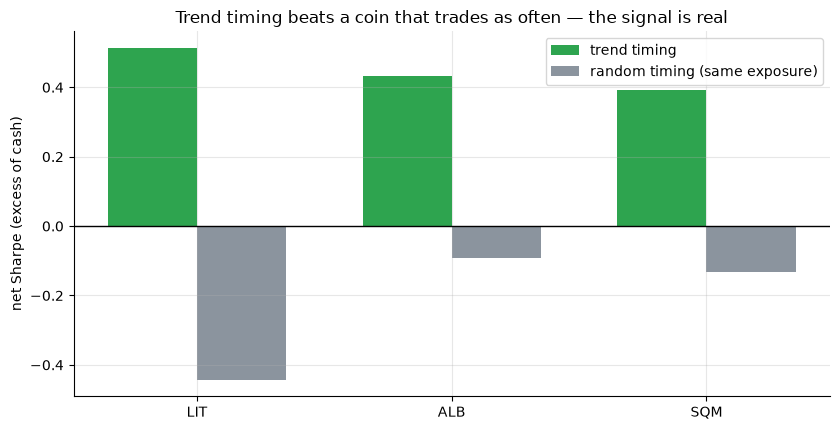

Random timing is a disaster (you buy dips that keep dipping); trend is far above it.


In [3]:
if HAVE_REAL:
    rows = []
    for t in THEME:
        bb = load(t); ss = st.trend_signal(bb, 200)
        bt = st.backtest(bb, ss, cost_bps=10.0, rf_annual=RF)
        expo = bt['pos'].mean()
        tr = st.sharpe(bt['strat_net'].to_numpy(), rf_daily=RF_D)
        rnd = [st.sharpe(st.backtest(bb, st.random_timing_signal(len(bb), expo, seed=s),
               cost_bps=10.0, rf_annual=RF)['strat_net'].to_numpy(), rf_daily=RF_D)
               for s in range(150)]
        rows.append((t, tr, np.nanmean(rnd)))
else:
    rows = [('LIT', 0.51, -0.45),
            ('ALB', 0.43, -0.09),
            ('SQM', 0.39, -0.14)]
labels = [r[0] for r in rows]; trs = [r[1] for r in rows]; rnds = [r[2] for r in rows]
x = np.arange(len(labels)); w = 0.35
fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.bar(x - w/2, trs, w, color=GREEN, label='trend timing')
ax.bar(x + w/2, rnds, w, color=GREY, label='random timing (same exposure)')
ax.axhline(0, c='k', lw=1); ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('net Sharpe (excess of cash)'); ax.legend()
ax.set_title('Trend timing beats a coin that trades as often — the signal is real')
plt.tight_layout(); plt.show()
print('Random timing is a disaster (you buy dips that keep dipping); trend is far above it.')

Random timing **destroys** you (mean Sharpe ~-0.45 on LIT) — you keep buying dips that keep dipping. The trend rule sits at the very top of that distribution (the **100th percentile**). So the *when* genuinely carried information. **The signal is real.**

**Question two — the catch: was that information worth any extra *return* over just holding LIT?** Here's the difference between the overlay and buy-and-hold, and the drawdown each suffered:

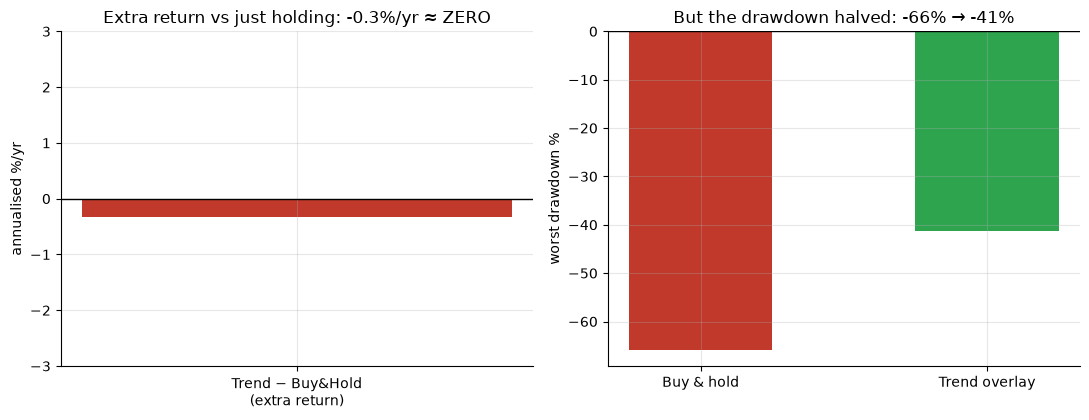

Extra return vs hold: -0.33%/yr   Drawdown: -66% -> -41%


In [4]:
if HAVE_REAL:
    b = load('LIT'); sig = st.trend_signal(b, 200)
    bt = st.backtest(b, sig, cost_bps=10.0, rf_annual=RF)
    diff_ann = np.nanmean(bt['strat_net'].to_numpy() - bt['asset_ret'].to_numpy())*252*100
    bh_dd = st.max_drawdown(bt['asset_ret'].to_numpy())*100
    tr_dd = st.max_drawdown(bt['strat_net'].to_numpy())*100
else:
    diff_ann, bh_dd, tr_dd = -0.33, -66, -41
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar(['Trend − Buy&Hold\n(extra return)'], [diff_ann],
       color=(GREEN if diff_ann > 0 else RED), width=.5)
a1.axhline(0, c='k', lw=1); a1.set_ylabel('annualised %/yr')
a1.set_ylim(-3, 3); a1.set_title(f'Extra return vs just holding: {diff_ann:+.1f}%/yr ≈ ZERO')
a2.bar(['Buy & hold', 'Trend overlay'], [bh_dd, tr_dd], color=[RED, GREEN], width=.5)
a2.axhline(0, c='k', lw=1); a2.set_ylabel('worst drawdown %')
a2.set_title(f'But the drawdown halved: {bh_dd:.0f}% → {tr_dd:.0f}%')
plt.tight_layout(); plt.show()
print(f'Extra return vs hold: {diff_ann:+.2f}%/yr   Drawdown: {bh_dd:.0f}% -> {tr_dd:.0f}%')

There it is. Versus simply holding LIT, the overlay added **~-0.3%/yr** — statistically **zero**. What it really did was cut the worst drawdown roughly in half (**-66% → -41%**). You didn't get *richer* from the boom; you got a *calmer ride* through the bust. That's a real and useful thing — but it is **not** the boom-riding return the super-cycle story sold.

## 5 · The verdict

- **Signal — Real.** The trend timing beats a same-exposure coin at the 100th percentile on all three battery names, and LIT's in-market return clears the bar (HAC *t* = +2.09 net). The *when* knew something.
- **Tradability — Fragile.** Net Sharpe ~0.5, a single thin thematic sleeve — and it earns *worse* risk-adjusted returns than just holding the S&P 500 (0.77).
- **Did riding the boom pay? — Misattributed.** The extra return over buy-and-hold is essentially zero. The benefit was a halved drawdown — *crash-dodging*, not *boom-riding*.

## 6 · Could you actually trade it?

Costs aren't the killer here — the rule flips only a handful of times a year. The killer is the comparison it loses: **just holding the S&P 500.**

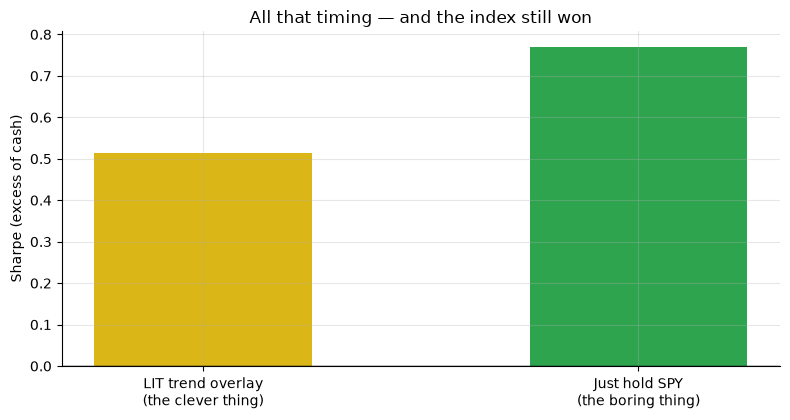

LIT trend overlay Sharpe 0.51  vs  SPY buy-and-hold 0.77


In [5]:
if HAVE_REAL:
    lit = st.sharpe(st.backtest(load('LIT'), st.trend_signal(load('LIT'),200),
                    cost_bps=10.0, rf_annual=RF)['strat_net'].to_numpy(), rf_daily=RF_D)
    spy = st.sharpe(load('SPY')['close'].pct_change().fillna(0).to_numpy(), rf_daily=RF_D)
else:
    lit, spy = 0.51, 0.77
fig, ax = plt.subplots(figsize=(8, 4.3))
b = ax.bar(['LIT trend overlay\n(the clever thing)', 'Just hold SPY\n(the boring thing)'],
           [lit, spy], color=[AMBER, GREEN], width=.5)
ax.set_ylabel('Sharpe (excess of cash)'); ax.axhline(0, c='k', lw=1)
ax.set_title('All that timing — and the index still won')
plt.tight_layout(); plt.show()
print(f'LIT trend overlay Sharpe {lit:.2f}  vs  SPY buy-and-hold {spy:.2f}')

The clever single-theme overlay lands at ~0.5; doing nothing but holding SPY scored ~0.77. You took on concentrated battery-metals risk, traded actively, and ended up with a *worse* risk-adjusted result than the couch portfolio. That's the definition of **fragile**: real, but not worth the bother.

## 7 · Going further 🚪

- **The parent rule, on broad indices.** [Study 116 — Faber-Timing](../../116-faber-timing/) tests the same 200-day SMA long-flat rule on the index itself — same finding family: great for drawdowns, thin on return.
- **Where trend *does* (barely) earn its keep.** [Study 20 — Freight-Train](../../20-freight-train/) and [Study 31 — Trade-Winds](../../31-trade-winds/) run trend across *many* markets — diversification is the only thing that rescues a thin per-sleeve Sharpe. Lithium-Boom is the one-sleeve case, and shows exactly why one sleeve is fragile.
- **Fork it.** Try a faster window, or add the trend sleeve to a 60/40 — does the drawdown-dodging help a *portfolio* even if it doesn't beat the asset? That's the honest use of a crash-dodging tool.

*Think the boom 'paid'? Fork this, and show me the extra return over just holding the thing — measured against cash, after costs. The drawdown chart is real; the return chart is the one the pitch never prints.*